# 01 - EDA

In [33]:
import sys
from pathlib import Path
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src").is_dir()) # root repoa koristimo kako bismo mogli da radimo importe iz src modula
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from scipy import ndimage
from skimage.morphology import remove_small_objects
from skimage.measure import label as sk_label, regionprops_table
from src.config import IMG_DIR, MASK_DIR, SEED
from src.utils import show_image_mask_and_overlay
import shutil

In [34]:
imgs = sorted(p.name for p in IMG_DIR.glob("*.png"))
masks = sorted(p.name for p in MASK_DIR.glob("*.png"))

## 1. Provera praznih maski

Učitaćemo txt fajl u kom se nalaze nazivi praznih maski, prekopiraćemo slike koje odgovaraju maskama u poseban folder i vizuelno ih proveriti.

In [35]:
empty_dir = ROOT/"data"/"prazne"

with open(empty_dir/"empty_masks.txt", "r") as f:
    empties = [id.strip() for id in f.readlines()]

# kopiramo slike iz liste u ROOT/data/prazne
for name in empties:
   shutil.copy(IMG_DIR/name, empty_dir/name)

Vizuelnim pregledom svih slika sa praznim maskama je utvrđeno da ili uopšte nema fluorescencije, ili se pojavljuje u nekim jako sitnim tačkicama ili je kao jako blag artefakt u pozadini ili se vidi debela fluorescentna traka. U principu nema vidljivih neurona što potvrđuje da je prazna maska validna oznaka (0 ćelija). Zato ih zadržavamo kao ispravne primere.

Pokazaćemo par nasumičnih primera u svesci.

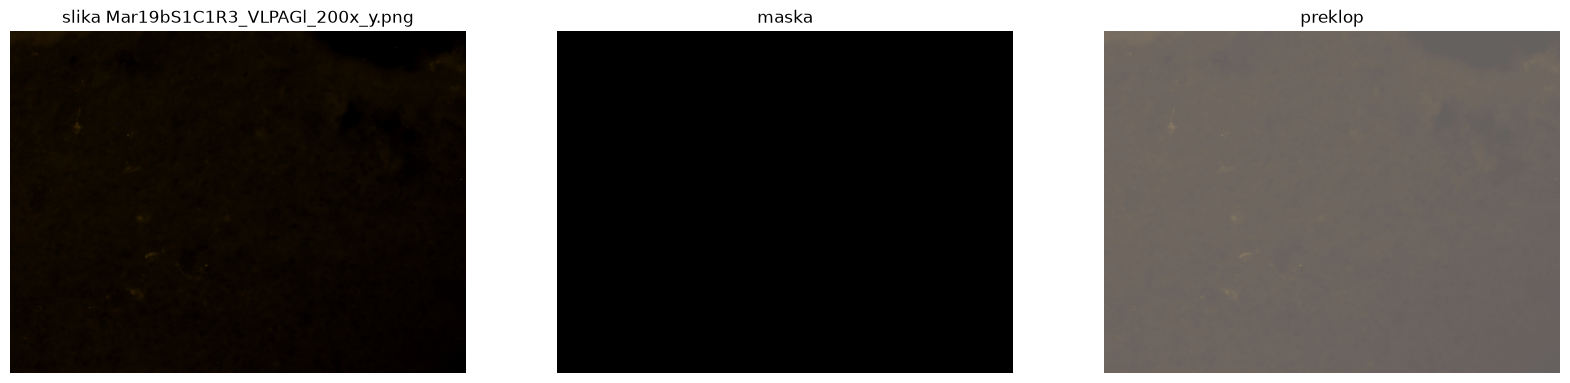

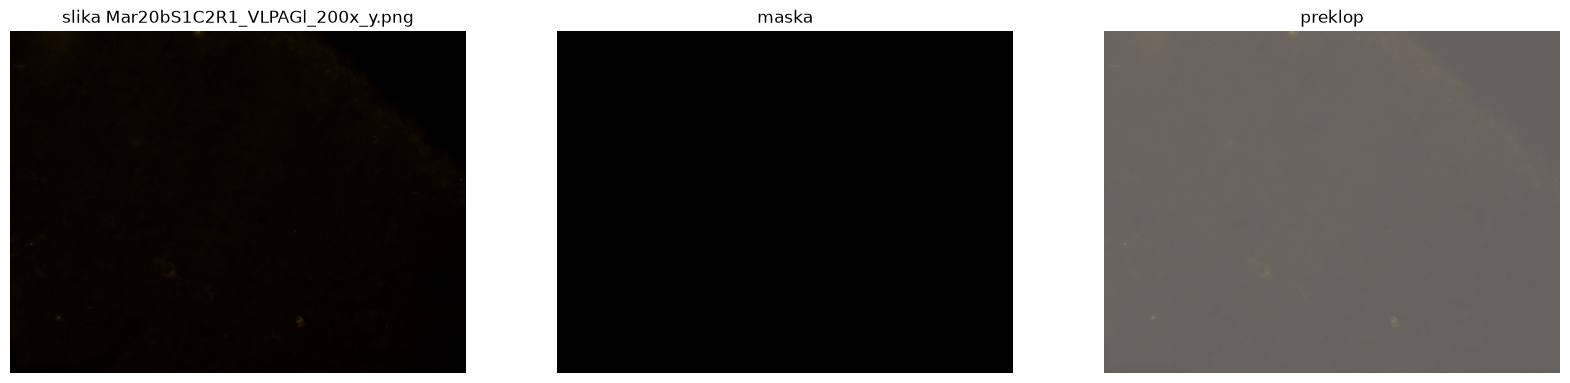

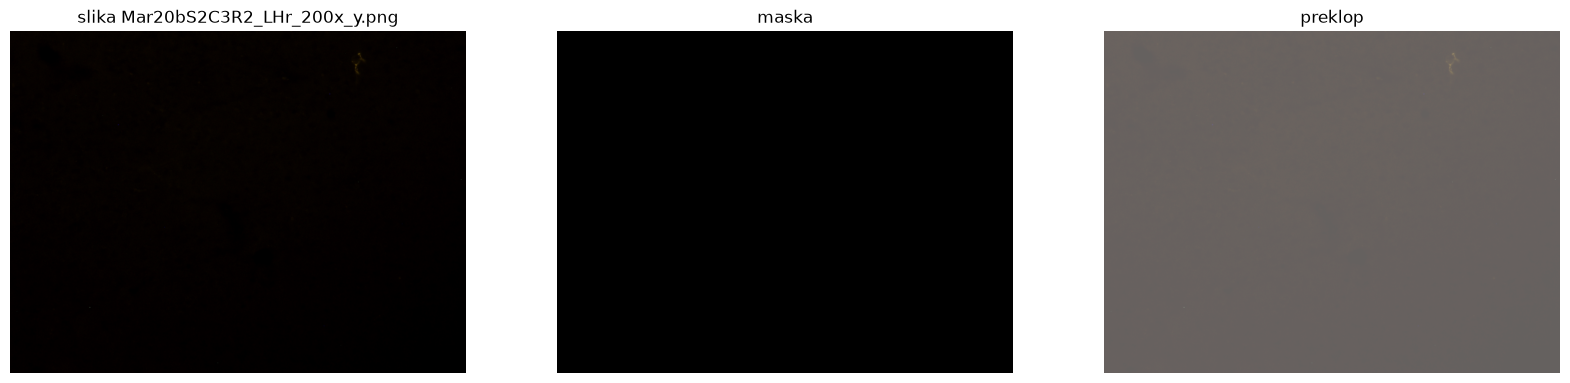

In [36]:
show_image_mask_and_overlay(empties[0])
show_image_mask_and_overlay(empties[7])
show_image_mask_and_overlay(empties[15])

## 2. Distribucija veličine objekata  i izbor praga za uklanjanje šuma
Pre nego što uklonimo „sitne" objekte kao šum, gledamo distribuciju veličina svih objekata
(površina u pikselima) iz ground truth (GT) maski. Prag nećemo preuzeti zdravo za gotovo iz izvora za projekat (Stanford rad koristi 40 bez
izvođenja, a originalni rad kaže 'few pixels') nego ga biramo iz ove distribucije + biološke procene (objekti reda ~40 px su najverovatnije
šum automatske segmentacije, ne realne ćelije).

Referenca: prosečna površina ćelije iz README-a je
1206 px².

Napomena: veliki objekti u repu mogu biti spojene dodirujuće ćelije (bez watershed-a za EDA), ali to ne utiče
na izbor donjeg praga za šum.

In [37]:
sizes_all = []
for name in imgs:
    m = np.array(Image.open(MASK_DIR/name)) > 0
    lab, n = ndimage.label(m)
    if n:
        areas = np.bincount(lab.ravel())[1:]   # površine objekata u px (bez pozadine)
        sizes_all.extend(areas.tolist())
sizes_all = np.array(sizes_all)
print("ukupno objekata (bez filtriranja):", sizes_all.size)
print("min:", int(sizes_all.min()), " max:", int(sizes_all.max()))
for p in [1,5,10,25,50,75,90,99]:
    print(f"  p{p:>2}: {np.percentile(sizes_all, p):.0f} px")

ukupno objekata (bez filtriranja): 2270
min: 1  max: 9360
  p 1: 1 px
  p 5: 233 px
  p10: 426 px
  p25: 713 px
  p50: 1136 px
  p75: 1838 px
  p90: 2870 px
  p99: 5785 px


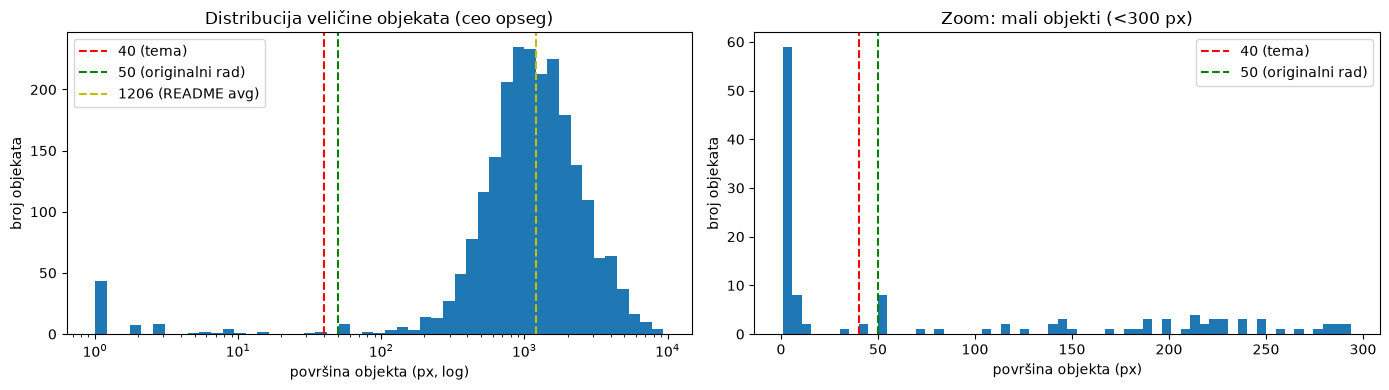

In [38]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))
ax[0].hist(sizes_all, bins=np.logspace(np.log10(sizes_all.min()), np.log10(sizes_all.max()), 50))
ax[0].set_xscale("log"); ax[0].set_xlabel("površina objekta (px, log)"); ax[0].set_ylabel("broj objekata")
ax[0].axvline(40, color="r", ls="--", label="40 (tema)")
ax[0].axvline(50, color="g", ls="--", label="50 (originalni rad)")
ax[0].axvline(1206, color="y", ls="--", label="1206 (README avg)")
ax[0].set_title("Distribucija veličine objekata (ceo opseg)"); ax[0].legend()
ax[1].hist(sizes_all[sizes_all < 300], bins=60)
ax[1].axvline(40, color="r", ls="--", label="40 (tema)")
ax[1].axvline(50, color="green", ls="--", label="50 (originalni rad)")
ax[1].set_xlabel("površina objekta (px)"); ax[1].set_ylabel("broj objekata")
ax[1].set_title("Zoom: mali objekti (<300 px)"); ax[1].legend()
plt.tight_layout(); plt.show()

### Izbor praga T = 80 px²
Prag biramo iz izmerene distribucije.
- Objekti <80 px² padaju u retku „dolinu šuma" i jasno su odvojeni od mase realnih ćelija koja počinje
  ~100 px² (pik ~1000–1300 px², što se poklapa sa prosečnom površinom 1206 px² iz README-a /
  skimage regionprops).
- Referentni prag 40 iz reference za projekat je naveden bez izvođenja, a originalni rad koristi samo „few pixels", pa nema
  preciznog standarda od kog bismo odstupili. 80 je isti red veličine, samo bolje potkrepljen našom
  distribucijom. Uticaj na finalne metrike je u principu mali jer uklanja samo sitan šum, pa uporedivost sa
  objavljenim performansama ostaje.
- Domenska procena (biolog) pregledom duplih nepraznih maski: objekti reda 40–80 px su šum automatske segmentacije, ne ćelije.
- Prag je deljen parametar sa evaluacijom (isti na GT i na predikcijama), zato želimo da budemo sigurni u dobar izbor. **Ali OPERATIVNU vrednost ne fiksiramo ovde — vidi napomenu o curenju ispod.**

> ⚠️ Napomena o data leaks: ovaj prag je izračunat nad CELIM skupom (uključujući i test)
> i ovde služi *ISKLJUČIVO* za deskriptivnu statistiku i upoznavanje podataka. Provizorno
> biramo T_EDA = 80 px². Prag koji utiče na EVALUACIJU (brojanje ntrue/npred za MAE/F1)
> mora biti TEST-NEZAVISAN — inače bismo test skupom podešavali evaluacionu proceduru.
> Zato OPERATIVNI prag izvodimo NAKNADNO, POSLE splita, na TRAIN+VAL skupu, istim
> objektivnim kriterijumom (gde se završava klaster šuma). Tek ta vrednost ide u
> `config.py` i utiče na evaluaciju. Rezultati su robustni za T∈[40,100], pa se očekuje ~80.

In [ ]:
T_EDA = 80   # px^2: PROVIZORAN prag, samo za deskriptivnu EDA (vidi napomenu o curenju iznad)

### Robusnost na izbor praga
Robusnost izbora proveravamo uvidom u uticaj izbora na ukupno detektovan broja ćelija za više vrednosti praga T.
Ako razlike nisu velike,
izbor praga nije kritičan (a mi biramo 80).

In [40]:
print("uticaj kandidata praga T (uklanja objekte < T):")
for T in [10,20,30,40,50,60,80,100]:
    removed = int((sizes_all < T).sum())
    print(f"  T={T:>3}: uklonjeno {removed:>4}/{sizes_all.size}  (ostaje {sizes_all.size-removed})")
print("\n30 najmanjih objekata (px):", sorted(sizes_all.tolist())[:30])

uticaj kandidata praga T (uklanja objekte < T):
  T= 10: uklonjeno   66/2270  (ostaje 2204)
  T= 20: uklonjeno   69/2270  (ostaje 2201)
  T= 30: uklonjeno   69/2270  (ostaje 2201)
  T= 40: uklonjeno   70/2270  (ostaje 2200)
  T= 50: uklonjeno   72/2270  (ostaje 2198)
  T= 60: uklonjeno   80/2270  (ostaje 2190)
  T= 80: uklonjeno   81/2270  (ostaje 2189)
  T=100: uklonjeno   82/2270  (ostaje 2188)

30 najmanjih objekata (px): [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]


Shvatamo da izbor praga nije kritičan u opsegu [10,100], pa provizorno usvajamo `T_EDA = 80` px²
za deskriptivnu EDA, potkrepljeno gore datim obrazloženjem.

**TODO (posle splita):** operativni `MIN_OBJECT_SIZE` izvesti u svesci 02 (ili posle splita) na
train+val, pa ga staviti u `config.py`.

## 3. Izvođenje broja ćelija iz maske
Nema zasebnog fajla sa brojem ćelija, pa broj moramo da izvedemo iz maske.

Ćelija = povezana grupa nenultih
piksela (connected component).

Postupak: binarizuj (`>0`), ukloni sitne objekte (< `T_EDA`),
prebroj komponente.

Prag `min_size` je provizoran `T_EDA = 80` px² iz sekcije 2 (samo deskriptivno).

In [41]:
def count_cells(mask_path, min_size=T_EDA):
    a = np.array(Image.open(mask_path)) > 0            # binarizacija
    a = remove_small_objects(a, min_size=min_size)     # ukloni šum
    lbl, n = ndimage.label(a)                          # povezane komponente
    return n

sample = imgs[:8]
for name in sample:
    print(name, "-> ćelija:", count_cells(MASK_DIR/name))

37_y.png -> ćelija: 5
38_y.png -> ćelija: 5
39_y.png -> ćelija: 6
MAR38S1C3R1_DML_20_o.png -> ćelija: 45
MAR38S1C3R1_DMR_20_o.png -> ćelija: 59
MAR38S1C3R1_LHR_20_o.png -> ćelija: 47
MAR39S2C2R2_DML_200x_o.png -> ćelija: 20
MAR39S2C2R2_DMR_200x_o.png -> ćelija: 20


/var/folders/zy/p1237_9j4xbgxpvlwy__jnzc0000gn/T/ipykernel_6120/3764526151.py:3: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  a = remove_small_objects(a, min_size=min_size)     # ukloni šum


## 4. Broj i dimenzije ćelija (GT maske)
Sve što sledi računa se na GT maskama: binarizacija `>0` i uklanjanje objekata manjih od provizornog
praga `T_EDA` (=80 px², §2).

Napomena: broj i dimenzije se računaju na povezanim komponentama, bez watershed-a koji u izvornom radu primenjuju u proceduri evaluacije, pa je moguće da će se zbijene ćelije koje se dodiruju brojati kao jedan objekat i da u nekoj meri podcenjujemo realnan broj.

In [42]:
H, W = 1200, 1600
areas, eqdiam, major, minor, ecc, centroids = [], [], [], [], [], []
rows_img = []
for name in imgs:
    m = np.array(Image.open(MASK_DIR/name)) > 0
    fg = int(m.sum())                                   # foreground pre uklanjanja (za imbalance)
    m2 = remove_small_objects(m, min_size=T_EDA)
    lab = sk_label(m2)
    p = regionprops_table(lab, properties=("area","equivalent_diameter",
        "major_axis_length","minor_axis_length","eccentricity","centroid"))
    n = len(p["area"])
    areas.extend(p["area"]); eqdiam.extend(p["equivalent_diameter"])
    major.extend(p["major_axis_length"]); minor.extend(p["minor_axis_length"])
    ecc.extend(p["eccentricity"])
    centroids.extend(zip(p["centroid-0"], p["centroid-1"]))
    rows_img.append(dict(name=name, broj=n, fg_px=fg, fg_pct=100*fg/(H*W),
                         max_area=(float(max(p["area"])) if n else 0.0)))
df_img = pd.DataFrame(rows_img)
areas = np.array(areas); eqdiam=np.array(eqdiam); major=np.array(major); minor=np.array(minor); ecc=np.array(ecc)
print("objekata ukupno:", len(areas), "| slika:", len(df_img))

/var/folders/zy/p1237_9j4xbgxpvlwy__jnzc0000gn/T/ipykernel_6120/3860775017.py:7: FutureWarning: Parameter `min_size` is deprecated since version 0.26.0 and will be removed in 2.0.0 (or later). To avoid this warning, please use the parameter `max_size` instead. For more details, see the documentation of `remove_small_objects`. Note that the new threshold removes objects smaller than **or equal to** its value, while the previous parameter only removed smaller ones.
  m2 = remove_small_objects(m, min_size=T_EDA)


objekata ukupno: 2188 | slika: 283


### 4.1 Broj ćelija po slici

po slici -> min: 0  max: 69  prosek: 7.73  medijana: 4  ukupno ćelija: 2188
praznih slika: 52  | >10 ćelija: 48  | >20: 27


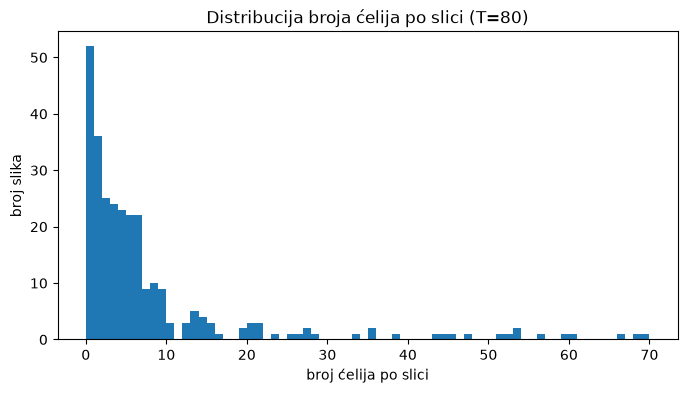

In [43]:
c = df_img["broj"]
print("po slici -> min:",int(c.min())," max:",int(c.max())," prosek:",round(c.mean(),2),
      " medijana:",int(c.median())," ukupno ćelija:",int(c.sum()))
print("praznih slika:", int((c==0).sum()), " | >10 ćelija:", int((c>10).sum()), " | >20:", int((c>20).sum()))
plt.figure(figsize=(8,4)); plt.hist(c, bins=range(0,int(c.max())+2))
plt.xlabel("broj ćelija po slici"); plt.ylabel("broj slika"); plt.title("Distribucija broja ćelija po slici (T=80)"); plt.show()

Vidmo pik u 0. To nam odgovara broju praznih maski + 2 sa po jednim objektom od 41px što je ispod praga za šum. Vidimo i da se na preostalim slikama uglavnom nalazi <10 ćelija. Skup podataka nema puno primera gde su ćelije gusto raspoređene, što nam potvrđuje da će za model biti izazovno da nauči da prepozna takve situacije i da će na njima.

### 4.2 Class imbalance (piksel-nivo)

ukupan udeo foreground (ćelija) piksela: 0.607%
po slici -> medijana: 0.445 % | max: 5.751 %


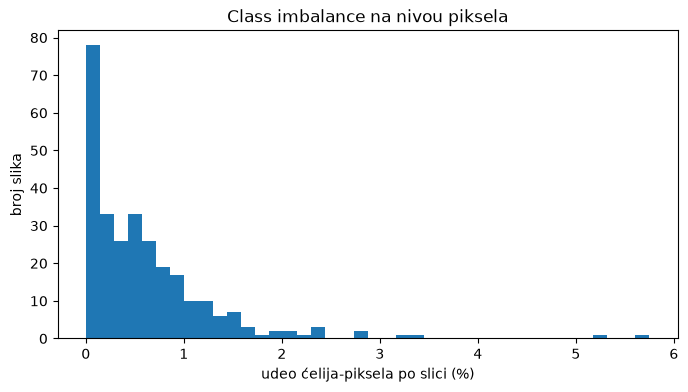

In [44]:
ukupno_fg = df_img["fg_px"].sum(); ukupno_px = len(df_img)*H*W
print(f"ukupan udeo foreground (ćelija) piksela: {100*ukupno_fg/ukupno_px:.3f}%")
print("po slici -> medijana:", round(df_img["fg_pct"].median(),3), "% | max:", round(df_img["fg_pct"].max(),3), "%")
plt.figure(figsize=(8,4)); plt.hist(df_img["fg_pct"], bins=40)
plt.xlabel("udeo ćelija-piksela po slici (%)"); plt.ylabel("broj slika"); plt.title("Class imbalance na nivou piksela"); plt.show()

Distribucija % piksela koji predstavljaju ćeliju po slici je izrazito iskrivljena ka levo. Medijana je 0.445%, a na slici sa najvećim udelom piksela koji pripadaju ćelijama, oni zauzimaju samo 5.751% cele slike. S obizrom da naš model u suštini uči da klasifikuje piksele u klasu 1/0 (predstavlja ćeliju ili ne) vidimo da je naš dataset izrazito nebalansiran.

Ovo nam govori da accuracy neće biti reprezentativna mera kvaliteta našeg modela, kao i da treba da korisitmo weighted loss funkciju za treniranje modela.

### 4.3 Dimenzije i oblik ćelija (regionprops) + poređenje sa opisom dataseta

            naše (prosek)     opis
area              1506.05  1206.43
equiv_diam          41.24    36.50
major               56.48    50.43
minor               33.54    29.39


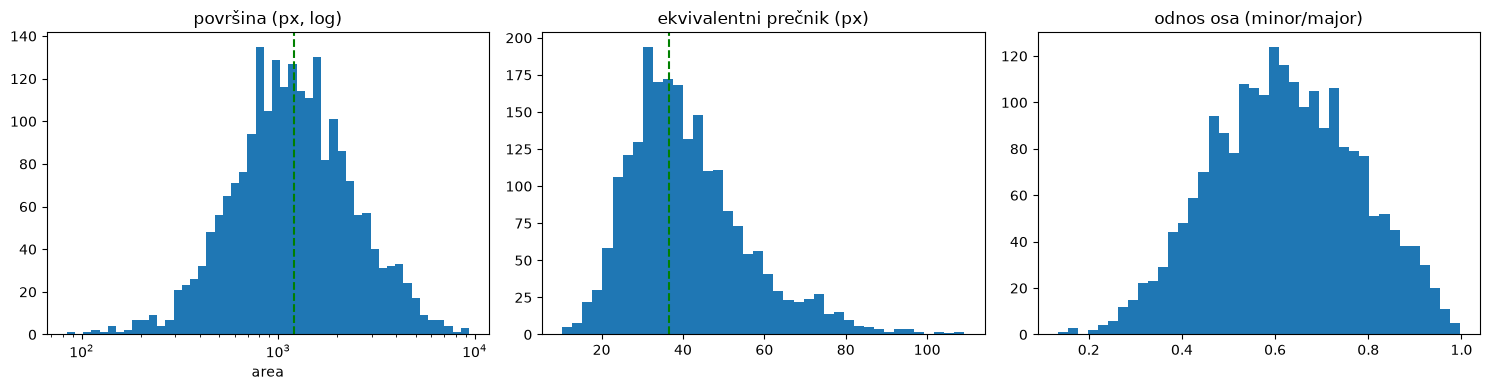

In [49]:
ours = dict(area=areas.mean(), equiv_diam=eqdiam.mean(), major=major.mean(), minor=minor.mean())
readme = dict(area=1206.43, equiv_diam=36.50, major=50.43, minor=29.39)
print(pd.DataFrame({"naše (prosek)":ours, "opis":readme}).round(2).to_string())
fig, ax = plt.subplots(1,3, figsize=(15,4))
ax[0].hist(areas, bins=np.logspace(np.log10(areas.min()),np.log10(areas.max()),50)); ax[0].set_xscale("log")
ax[0].axvline(1206, color="g", ls="--"); ax[0].set_title("površina (px, log)"); ax[0].set_xlabel("area")
ax[1].hist(eqdiam, bins=40); ax[1].axvline(36.5, color="g", ls="--"); ax[1].set_title("ekvivalentni prečnik (px)")
ax[2].hist((minor/np.clip(major,1,None)), bins=40); ax[2].set_title("odnos osa (minor/major)")
plt.tight_layout(); plt.show()

Naše izmerene prosečne dimenzije su istog reda veličine kao opis dataseta,
ali sistematski veće (površina 1506 vs 1206 px², ekvivalentni prečnik 41.2 vs 36.5 px). Veći prosek očekivano dolazi otud
što (a) NE primenjujemo watershed, pa se dodirujuće ćelije spajaju u jedan veći objekat i podižu
srednju površinu, i (b) uklanjamo objekte <80 px², čime izbacujemo baš najsitnije vrednosti.
Oba efekta guraju naš prosek naviše, što se slaže sa razlikom koju vidimo.


Ključno je da se oblik poklapa detektovanih objekata, tj. ćelija poklapa. Odnos osa minor/major kod nas je 33.54/56.48 ≈ 0.59, a u opisu
29.39/50.43 ≈ 0.58, dakle detektujemo istu izduženost ćelija. To potvrđuje da naša regionprops logika radi
ispravno i da objekti odgovaraju opisanoj morfologiji neurona. 

### 4.4 Zbijenost / clumping

najveći objekat po slici (px) -> medijana: 2392  max: 9360
objekata > 3× prosečne površine (kandidati za spojene klastere): 63


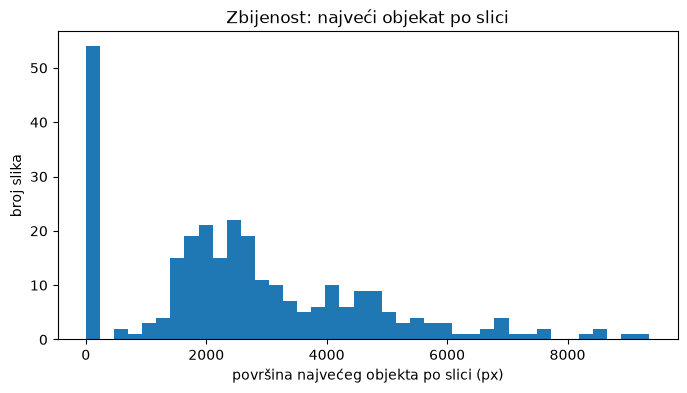

In [48]:
print("najveći objekat po slici (px) -> medijana:", int(df_img["max_area"].median()),
      " max:", int(df_img["max_area"].max()))
# objekti mnogo veći od proseka su kandidati za dodirujuće ćelije
vel = int((areas > 3*1506.05).sum())
print(f"objekata > 3× prosečne površine (kandidati za spojene klastere): {vel}")
plt.figure(figsize=(8,4)); plt.hist(df_img["max_area"], bins=40)
plt.xlabel("površina najvećeg objekta po slici (px)"); plt.ylabel("broj slika"); plt.title("Zbijenost: najveći objekat po slici"); plt.show()

Medijana najvećeg objekta po slici je 2392 px² - skoro 2× prosečna površina
ćelije (1206 px² iz opisa), a maksimum ide do 9360 px² (~8× prosek). Uz to, 63 objekta prelaze 3×
prosečnu površinu i kandidati su za spojene, tj. dodirujuće ćelije. Dakle tipična slika sadrži bar
jedan „slepljen" klaster. Pošto u EDA ne koristimo watershed, takvi klasteri se broje kao jedan
objekat, pa u gustim slikama podcenjujemo realan broj ćelija.

Ovo direktno objašnjava zašto će
recall na gustim/zbijenim slikama biti najteži deo problema i motiviše
watershed u proceduri evaluacije brojanja.

### 4.5 Prostorna raspodela centroida ćelija

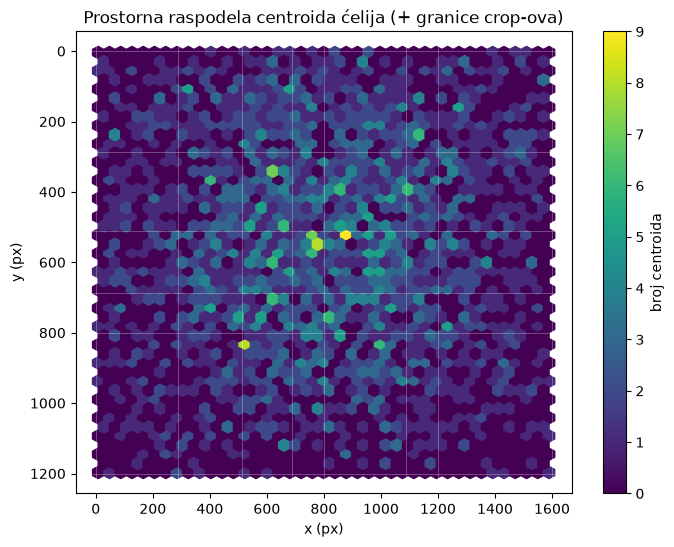

In [15]:
cy = np.array([r for r,_ in centroids]); cx = np.array([c for _,c in centroids])
plt.figure(figsize=(8,6))
plt.hexbin(cx, cy, gridsize=40, cmap="viridis"); plt.gca().invert_yaxis(); plt.colorbar(label="broj centroida")
# granice 512² crop-prozora
for x in [0,288,688,1088,512,800,1200,1600]: plt.axvline(x, color="w", lw=0.4, alpha=0.5)
for y in [0,288,688,512,800,1200]: plt.axhline(y, color="w", lw=0.4, alpha=0.5)
plt.xlabel("x (px)"); plt.ylabel("y (px)"); plt.title("Prostorna raspodela centroida ćelija (+ granice crop-ova)"); plt.show()

Centroidi pokrivaju ceo kadar (nema praznih regiona), ali raspodela nije
ravnomerna, već je vidljiva koncentracija ka centru slike
sa proređivanjem ka ivicama i uglovima i tankim skoro praznim rubom uz samu granicu.

Ovo ima dve implikacije za kropovanje:<br>(1) pošto uz samu ivicu ima vrlo malo ćelija, rizik da spoljašnji krop-prozori seku
ćelije na granici je mali<br>
(2) centralni region je gušći i skladno tome
ga pokriva više preklapajućih prozora (pomak 112 px), pa su ćelije iz centra i prirodno i kroz
kropovanje dobro zastupljene u trening skupu. Nijedan prozor nije „prazan po difoltu".

Uz to, centriranost
verovatno odražava način snimanja (vidno polje mikroskopa ka sredini), a ne artefakt maski.

## 5. Intenzitet slika (priprema za odluku o normalizaciji)
Radovi na kojima se oslanjamo ne navode recept za normalizaciju ulaznih slika, pa tu odluku donosimo
sami. Zato ovde karakterišemo raspodelu intenziteta: da bismo izabrali strategiju normalizacije
(skaliranje na [0,1] vs standardizacija po kanalu) i odlučili kako da rukujemo kanalima
(sva tri RGB kanala vs jedan, ako su međusobno redundantni).

> ⚠️ Napomena o data leaks: statistike se ovde računaju nad celim skupom i služe
> isključivo za deskripciju. Ako se odlučimo za standardizaciju, srednja vrednost i
> std koji ulaze u model računaju se naknadno, samo na train skupu (posle splita), i
> primenjuju na val/test, kako nebismo test skupom podešavali preprocesiranje.

### 5.1 Statistike i histogram intenziteta po kanalu

In [53]:
# akumuliramo histogram po kanalu
print("shape prve slike:", np.array(Image.open(IMG_DIR/imgs[0])).shape)

H_int = np.zeros((3, 256), dtype=np.int64)
for name in imgs:
    a = np.array(Image.open(IMG_DIR/name))
    for ch in range(3):
        H_int[ch] += np.bincount(a[:, :, ch].ravel(), minlength=256)

# statistike računamo iz histograma (bez čuvanja svih piksela)
vals = np.arange(256)
stat = {}
for ch, ime in enumerate(["R", "G", "B"]):
    h = H_int[ch]; n = h.sum(); cum = np.cumsum(h)
    mean = (vals * h).sum() / n
    std = np.sqrt((h * (vals - mean)**2).sum() / n)
    nz = np.nonzero(h)[0]
    perc = lambda q: int(np.searchsorted(cum, q * n))   # percentil iz kumulativne sume
    stat[ime] = dict(mean=round(float(mean), 2), std=round(float(std), 2),
                     min=int(nz[0]), max=int(nz[-1]),
                     p1=perc(0.01), p50=perc(0.50), p99=perc(0.99))
df_int = pd.DataFrame(stat).T[["mean", "std", "min", "max", "p1", "p50", "p99"]]
print()
print(df_int.to_string())

shape prve slike: (1200, 1600, 3)

    mean    std  min    max   p1  p50   p99
R  10.62  15.97  0.0  255.0  0.0  7.0  72.0
G   5.02  11.59  0.0  255.0  0.0  2.0  45.0
B   0.32   1.38  0.0  217.0  0.0  0.0   5.0


Srednje vrednosti po kanalu su niske
(R=10.62, G=5.02, B=0.32 na skali 0–255), tj. sve slike su vrlo tamne. Ovo potvrđuje tezu da pozadina dominira iz prethodne sekcije. 

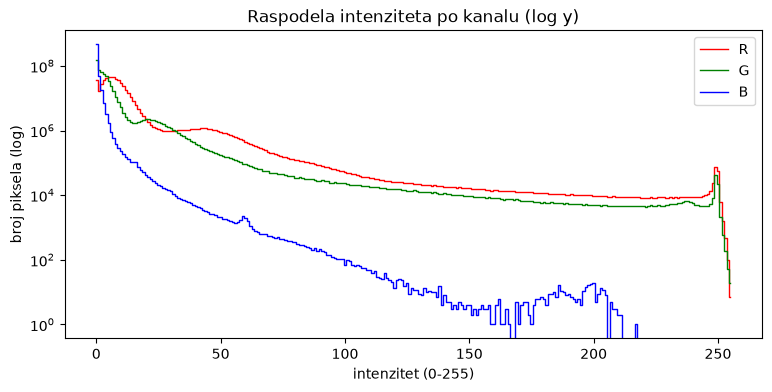

In [54]:
plt.figure(figsize=(9,4))
for ch, (ime, boja) in enumerate(zip(["R","G","B"], ["red","green","blue"])):
    plt.step(vals, H_int[ch], where="mid", color=boja, lw=1, label=ime)
plt.yscale("log")
plt.xlabel("intenzitet (0-255)"); plt.ylabel("broj piksela (log)")
plt.title("Raspodela intenziteta po kanalu (log y)"); plt.legend(); plt.show()

Raspodela intenziteta je izrazito iskrivljena, praktično
bimodalna: ogroman pik na ~0 (pozadina) + dug, slab rep ka svetlim vrednostima, tj. signalu
ćelija.

R i G imaju vidljivo „rame" u opsegu ~15–50 (signal), dok B najbrže opada. Blizu
255 postoji mali pik saturacije na R i G → poneki zasićen (clipped) piksel u najsvetlijim
jezgrima ćelija (efekat je mali, ali postoji). <br><br>**Implikacija za normalizaciju:** [0,1] skaliranje je jednostavan baseline
bez parametara i svodi sve kanale, koji su već na istoj skali (0–255) u ujednačen opseg.
Standardizacija (oduzmi mean / ÷std) neće promeniti oblik raspodele
niti razdvojivost signala i pozadine, a njen efekat (centriranje/skaliranje po kanalu)
model može da nauči interno. Zato je za sada preskačemo. Ostaje opciona i ako se doda,
mean/std samo na train.

### 5.2 Redundantnost kanala

In [56]:
# korelacija kanala na nasumičnom uzorku piksela (~2000 po slici)
rng = np.random.default_rng(SEED)
uzorci = []
for name in imgs:
    a = np.array(Image.open(IMG_DIR/name))
    if a.ndim != 3 or a.shape[2] != 3:
        continue
    flat = a.reshape(-1, 3)
    idx = rng.choice(flat.shape[0], size=2000, replace=False)
    uzorci.append(flat[idx])
uzorak = np.vstack(uzorci)
print("uzorak piksela:", uzorak.shape)

corr = np.corrcoef(uzorak.T)
print("\nkorelacija kanala:")
print(pd.DataFrame(corr, index=["R","G","B"], columns=["R","G","B"]).round(4).to_string())
print("\nsrednje vrednosti po kanalu (iz 5.1):", df_int["mean"].to_dict())

uzorak piksela: (566000, 3)

korelacija kanala:
        R       G       B
R  1.0000  0.9718  0.8037
G  0.9718  1.0000  0.8370
B  0.8037  0.8370  1.0000

srednje vrednosti po kanalu (iz 5.1): {'R': 10.62, 'G': 5.02, 'B': 0.32}


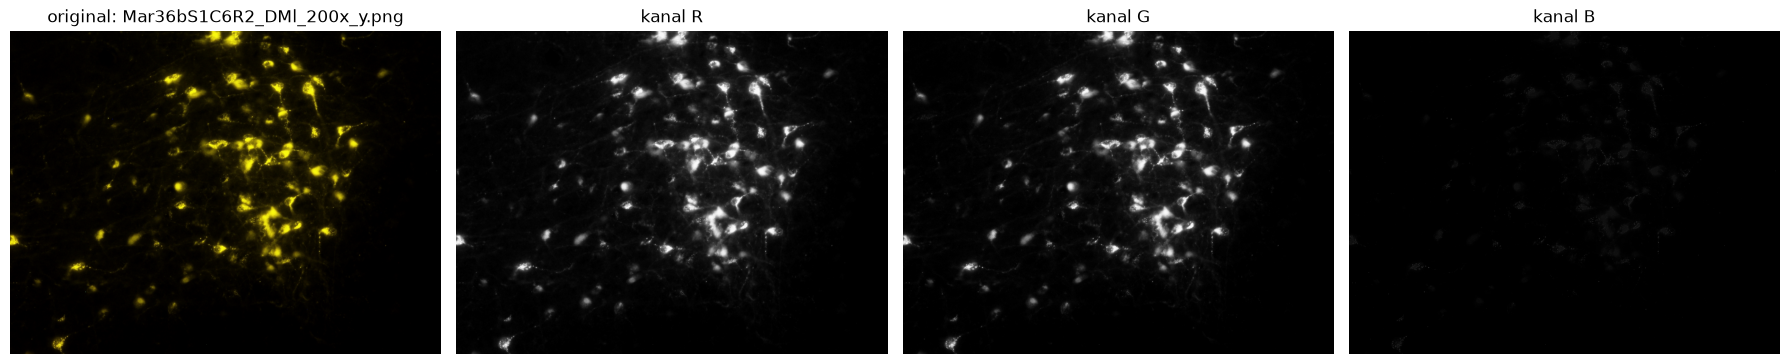

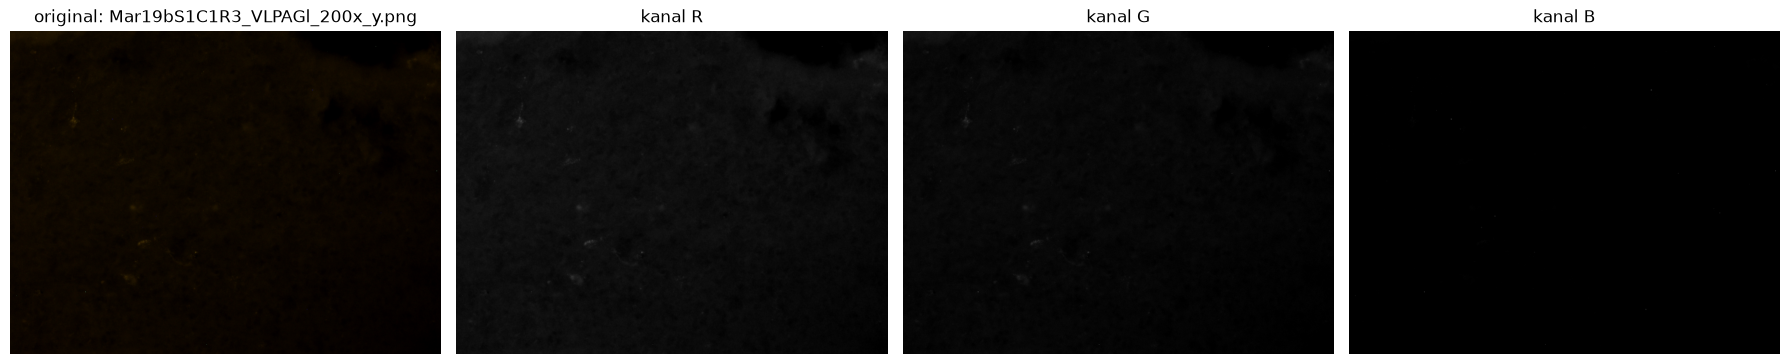

In [57]:
# vizuelni pregled kanala: jedna gusta i jedna prazna slika
gusta = df_img.loc[df_img["broj"].idxmax(), "name"]
prazna = empties[0]
for name in [gusta, prazna]:
    a = np.array(Image.open(IMG_DIR/name))
    fig, ax = plt.subplots(1, 4, figsize=(18,4))
    ax[0].imshow(a); ax[0].set_title(f"original: {name}")
    for ch, ime in enumerate(["R","G","B"]):
        ax[ch+1].imshow(a[:, :, ch], cmap="gray", vmin=0, vmax=255)
        ax[ch+1].set_title(f"kanal {ime}")
    for x in ax: x.axis("off")
    plt.tight_layout(); plt.show()

Signal je žuti fluorofor koncentrisan u R i G kanalu, dok je B kanal
gotovo prazan (mean 0.32) i vizuelno skoro crn čak i na gustoj slici. To znači da on nosi malo do nimalo
signala. R i G su visoko korelisani (0.9718) → u velikoj meri redundantni (žuto ≈ R+G).
Korelacije B sa R/G (0.80–0.84) deluju visoko, ali ih naduvava zajednička ogromna tamna
pozadina (svuda ~0), a ne deljeni signal. To vizuelni pregled kanala potvrđuje.
<br><br>**Implikacija za rukovanje kanalima:** korisna informacija je efektivno u 1–2 kanala. Za
baseline zadržavamo sva 3 kanala (RGB) jer c-ResUnet ima početni 1×1 conv koji može sam da nauči da pretegne R,G i priguši B.